


##Tareas:
* En este caso no hare analisis EDA.
* importa data ver si existe valores nulos.
* procesar la data.
* separa la data de entrenamiento y testeo
* crear modelos.


###Realizar 3 modelos:
1. Regression Logistica
2. Neuronal
3. SVM

> Importamos librerias

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE as smote

In [ ]:
datos = pd.read_csv('Churn_Modelling.csv')
datos.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


exploramos la data

In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Verificamos si existen valores nulos.

In [ ]:
if datos.isnull().sum().sum() == 0:
    print("No existen valores nulos")
else:
    print("Existen valores nulos")

No existen valores nulos


####RowNumber, CustomerID, Surname no nos dicen nada de utilidad son irrelavantes para el modelo. Si predecir si alguien va a darse de baja por su ID de cliente, apellido o numero de renglon en la base de datos no nos va a dar buenos resultados.




In [ ]:
df = datos.drop(columns=["RowNumber", "CustomerId", "Surname", "Exited"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
# Veamos si los datos estan equilibrados
datos["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [ ]:
bri = sns.color_palette("hls", 2)
sns.set_palette(bri)

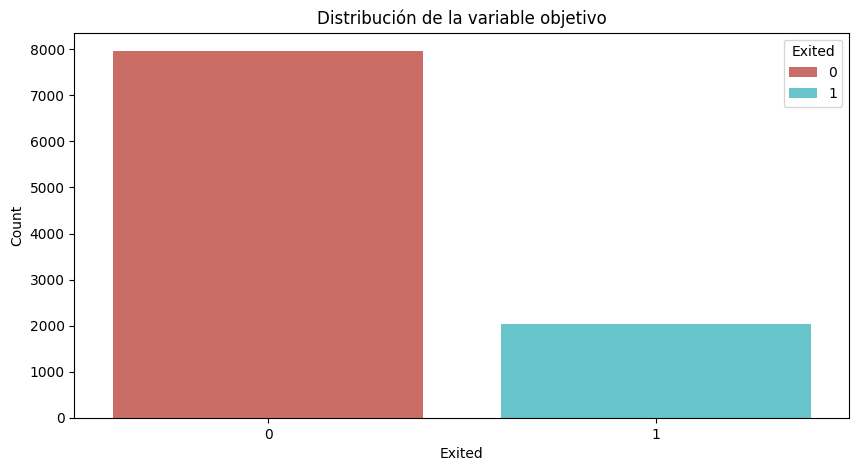

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=datos, x="Exited", palette=bri, hue="Exited")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.title("Distribución de la variable objetivo")
plt.show()

In [ ]:
# df_x = variables predictoras
# df_y = variable indpendiente
y = datos[datos.columns[-1]]
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [ ]:
X= datos.drop(columns=["RowNumber", "CustomerId", "Surname", "Exited"])
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


##Las columnas que son categoricas las vamos a transformar con one hot encoding (Genero y ubicacion geográfica) porque estos modelos solo procesan numeros.

In [ ]:
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


In [ ]:
X= pd.get_dummies(X)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,True,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,True,False


In [ ]:
# Convertir columnas booleanas a int
bool_columns = X.select_dtypes(include=['bool']).columns
for col in bool_columns:
    X[col] = X[col].astype(int)
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,1,0


In [ ]:
print('Shape df_x:',X.shape[0],'\n','Shepe df_y:',y.shape[0])

Shape df_x: 10000 
 Shepe df_y: 10000


Los datos estan desequlibrados
quiero probar varias cosa.
1. Para la regression logistica vamos a usar 1 forma de quitar el problema
2. Tambien otra escalando la data
3. smote

# ESCALANDO LA DATA

In [ ]:
#escalador = StandardScaler()
#X = escalador.fit_transform(X)
#print(X)

## Divivdimos la data en 80, 20

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)
model = LogisticRegression(C=1.0,penalty='l2',random_state=1,solver="newton-cg",class_weight="balanced")

#MODELO: Regression Logistica

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/scipy/optimize/_linesearch.py:313: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/optimize.py:44: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/optimize.py:211: ConvergenceWarning: newton-cg failed to converge. Increase the number of iterations.
  warnings.warn(


LogisticRegression(class_weight='balanced', random_state=1, solver='newton-cg')

In [ ]:
y_pred = model.predict(X_test)
print("Exactitud: ",accuracy_score(y_test, y_pred).round(2))

Exactitud:  0.71


# El primer modelo predice con una exactitud de un 71%.


# Otras estadisticas

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1617
           1       0.36      0.66      0.46       383

    accuracy                           0.71      2000
   macro avg       0.63      0.69      0.63      2000
weighted avg       0.80      0.71      0.73      2000



#Intentare hacer la tecnica de smote

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
smote_X, smote_y = smote.fit_resample(X,y)

model1 = LogisticRegression()
model1.fit(smote_X, smote_y)
y_pred = model1.predict(X_test)
print("Exactitud: ",accuracy_score(y_test, y_pred).round(2))

Exactitud:  0.64


usando la tecnica de smote me fue peor no entiendo porque


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.66      0.75      1617
           1       0.29      0.58      0.38       383

    accuracy                           0.64      2000
   macro avg       0.58      0.62      0.57      2000
weighted avg       0.76      0.64      0.68      2000



# MODELO RandomForestClassifier

In [101]:
# Tecnica de smote(ayuda a la data desquilibrada)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Mi primer modelo RandomForestClassifier
model_ramdonforest = RandomForestClassifier(random_state=42)
model_ramdonforest.fit(X_train_res, y_train_res)

# Predecion
y_pred = model_ramdonforest.predict(X_test)

In [118]:
print("Exactitud:",accuracy_score(y_test, y_pred).round(2))

Exactitud: 0.85


In [112]:
print("Exactitud:")
model_ramdonforest.score(smote_X, smote_y).round(2)

Exactitud:


0.85

probamos predicir un valor a ver si funciona

In [119]:
# Obtenemos una sola muestra para predecir
muestra = X_test.iloc[[5]]

# Hacemos la predicción
prediccion = model_ramdonforest.predict(muestra)

# Obtenemos el valor real correspondiente
valor_real = y_test.iloc[5]

# Imprimimos los resultados
print("Valor real:", valor_real)
print("Predicción:", prediccion[0])

# Funciona?
if prediccion[0] == valor_real:
    print("El modelo acertó")
else:
    print("El modelo fallo")

Valor real: 0
Predicción: 0
El modelo acertó


## Otras estadisticas interesantes

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.92      0.91      1617
           1       0.62      0.52      0.56       383

    accuracy                           0.85      2000
   macro avg       0.75      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000



MODELO SVM

In [ ]:
modelo_svm = svm.SVC(probability=True)
modelo_svm.fit(X_train, y_train)
y_pred = modelo_svm.predict(X_test)

In [ ]:
modelo_svm.decision_function_shape = "ovr"
modelo_svm.decision_function(X_test)[:10]

array([-0.99968993, -0.99963586, -1.00027376, -1.00028474, -1.00024072,
       -1.0002855 , -0.99973832, -1.00033052, -1.00010932, -0.99973835])

In [ ]:
modelo_svm.predict_proba(X_test)[:10]

array([[0.78218752, 0.21781248],
       [0.78005233, 0.21994767],
       [0.80428724, 0.19571276],
       [0.80468623, 0.19531377],
       [0.80308326, 0.19691674],
       [0.80471364, 0.19528636],
       [0.78408567, 0.21591433],
       [0.80634256, 0.19365744],
       [0.79823937, 0.20176063],
       [0.78408674, 0.21591326]])

In [ ]:
modelo_svm.predict(X_test)[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
modelo_svm.score(X_test, y_test).round(2)

0.81

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      1.00      0.89      1617
           1       0.00      0.00      0.00       383

    accuracy                           0.81      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.81      0.72      2000



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


1. , Regression Logistica, predicion 71%
2. ,SVM predicion, 81%
3. , RandomForestClassifier, predicion 85%
